# Baltimore - Seattle Weather Project

## Project Overview:

#### This project aims to compare the amount of rain in Seattle, WA and Baltimore, MD. This project utilizes data from [NOAA National Centers for Environmental Information](https://www.ncei.noaa.gov/cdo-web/). The data sets contain weather related observations for Baltimore and Seattle over the time period, January 1st, 2018 to December 31st, 2022. 

Code should be run in the order it appears. For the best results, run all cells at once. If an error appears, run all cells above the error before proceding.

## Data Cleaning

### Importing neccesary libaries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

### Loading the data sets

In [2]:
df_seattle = pd.read_csv('seattle_rain.csv')
df_seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [3]:
df_seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [4]:
df_balt= pd.read_csv('balt_rain.csv')
df_balt.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",2018-01-01,0.0,0.0,0.0
1,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",2018-01-02,0.0,0.0,0.0
2,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",2018-01-03,0.0,0.0,0.0
3,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",2018-01-04,0.1,0.9,1.2
4,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",2018-01-05,0.0,0.0,1.2


In [5]:
df_balt.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1826 non-null   str    
 1   NAME     1826 non-null   str    
 2   DATE     1826 non-null   str    
 3   PRCP     1826 non-null   float64
 4   SNOW     1826 non-null   float64
 5   SNWD     1826 non-null   float64
dtypes: float64(3), str(3)
memory usage: 210.5 KB


### Reviewing name and station columns

In [6]:
df_balt.columns

Index(['STATION', 'NAME', 'DATE', 'PRCP', 'SNOW', 'SNWD'], dtype='str')

In [7]:
df_seattle.columns

Index(['STATION', 'NAME', 'DATE', 'DAPR', 'MDPR', 'PRCP', 'SNOW', 'SNWD',
       'WESD', 'WESF'],
      dtype='str')

In [8]:
df_seattle['STATION']

0       US1WAKG0225
1       US1WAKG0225
2       US1WAKG0225
3       US1WAKG0225
4       US1WAKG0225
           ...     
1653    US1WAKG0225
1654    US1WAKG0225
1655    US1WAKG0225
1656    US1WAKG0225
1657    US1WAKG0225
Name: STATION, Length: 1658, dtype: str

In [9]:
df_seattle['STATION'].nunique()


1

In [10]:
df_balt['STATION']

0       USW00093721
1       USW00093721
2       USW00093721
3       USW00093721
4       USW00093721
           ...     
1821    USW00093721
1822    USW00093721
1823    USW00093721
1824    USW00093721
1825    USW00093721
Name: STATION, Length: 1826, dtype: str

In [11]:
df_balt['STATION'].nunique()

1

In [12]:
df_seattle['NAME'].nunique()

1

In [13]:
df_balt['NAME'].nunique()

1

Both dataframes only contain observations from one unique station. 

### Standardizing the format of date and filtering for target date range

In [14]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: str

In [15]:
df_balt['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1821    2022-12-27
1822    2022-12-28
1823    2022-12-29
1824    2022-12-30
1825    2022-12-31
Name: DATE, Length: 1826, dtype: str

In [16]:
df_seattle['DATE']=pd.to_datetime(df_seattle['DATE'], format='%m/%d/%y')

In [17]:
df_balt['DATE']=pd.to_datetime(df_seattle['DATE'], format='%Y-%m-%d')

In [18]:
df_seattle['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[us]

In [19]:
df_balt['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1821          NaT
1822          NaT
1823          NaT
1824          NaT
1825          NaT
Name: DATE, Length: 1826, dtype: datetime64[us]

In [20]:
df_seattle['DATE'].min()

Timestamp('2018-01-01 00:00:00')

In [21]:
df_seattle['DATE'].max()

Timestamp('2022-12-31 00:00:00')

In [22]:
df_balt['DATE'].min()

Timestamp('2018-01-01 00:00:00')

In [23]:
df_balt['DATE'].max()

Timestamp('2022-12-31 00:00:00')

In [24]:
df_balt = df_balt.loc[df_balt['DATE']>='2018-01-01']

Both datasets now include time for only the desired timeframe in a consistent format. Baltimore has several 'NaT' dates. 

### Adding in missing dates

For the target date range, there should be 1826 dates included. Baltimore has 1658 entries.

In [25]:
df_balt['DATE']

0      2018-01-01
1      2018-01-02
2      2018-01-03
3      2018-01-04
4      2018-01-05
          ...    
1653   2022-12-27
1654   2022-12-28
1655   2022-12-29
1656   2022-12-30
1657   2022-12-31
Name: DATE, Length: 1658, dtype: datetime64[us]

In [26]:
complete_datetime = pd.date_range(start=df_balt['DATE'].min(), end=df_balt['DATE'].max())

In [27]:
df_completedate = pd.DataFrame(complete_datetime, columns=['DATE'])

In [28]:
df_balt = pd.merge(df_completedate, df_balt, on='DATE', how='left')

In [29]:
df_balt.info()

<class 'pandas.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   DATE     1826 non-null   datetime64[us]
 1   STATION  1658 non-null   str           
 2   NAME     1658 non-null   str           
 3   PRCP     1658 non-null   float64       
 4   SNOW     1658 non-null   float64       
 5   SNWD     1658 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 183.3 KB


In [30]:
df_balt.head()

,DATE,STATION,NAME,PRCP,SNOW,SNWD
0,2018-01-01,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",0.0,0.0,0.0
1,2018-01-02,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",0.0,0.0,0.0
2,2018-01-03,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",0.0,0.0,0.0
3,2018-01-04,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",0.1,0.9,1.2
4,2018-01-05,USW00093721,"BALTIMORE WASHINGTON INTERNATIONAL AIRPORT, MD US",0.0,0.0,1.2


Baltimore data frame now has the appropriate number of entires for the desired timeframe. All other rows show 1658 non-null values. This corresponds to the number of entries before the missing dates were added. All previously missing dates now have null values for all other fields. 

### Merging Baltimore and Seattle data frames

In [31]:
df = df_balt[['DATE','PRCP']].merge(df_seattle[['DATE', 'PRCP']], on='DATE', how='outer')

In [32]:
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.0,0.00
1,2018-01-02,0.0,0.00
2,2018-01-03,0.0,0.00
3,2018-01-04,0.1,0.00
4,2018-01-05,0.0,0.25


In [33]:
df.describe()

,DATE,PRCP_x,PRCP_y
count,1826,1658.000000,1636.000000
mean,2020-07-01 12:00:00,0.142159,0.111852
min,2018-01-01 00:00:00,0.000000,0.000000
25%,2019-04-02 06:00:00,0.000000,0.000000
50%,2020-07-01 12:00:00,0.000000,0.010000
75%,2021-09-30 18:00:00,0.060000,0.110000
max,2022-12-31 00:00:00,4.790000,2.600000
std,NaN,0.389747,0.248635


Dataframe now contains only precipitation information for x(Baltimore) and y(Seattle).

### Creating a Tidy Dataframe

In [34]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [35]:
df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.0
1,2018-01-02,PRCP_x,0.0
2,2018-01-03,PRCP_x,0.0
3,2018-01-04,PRCP_x,0.1
4,2018-01-05,PRCP_x,0.0


In [36]:
df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.0
1,2018-01-02,PRCP_x,0.0
2,2018-01-03,PRCP_x,0.0
3,2018-01-04,PRCP_x,0.1
4,2018-01-05,PRCP_x,0.0


In [37]:
df.tail()

,DATE,city,precipitation
3647,2022-12-27,PRCP_y,0.78
3648,2022-12-28,PRCP_y,0.40
3649,2022-12-29,PRCP_y,0.03
3650,2022-12-30,PRCP_y,0.62
3651,2022-12-31,PRCP_y,0.17


### Re-naming columns for clarity

In [38]:
df = df.rename(columns={'DATE': 'date'})

In [39]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'BALT'

In [40]:
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

In [41]:
df.tail()

,date,city,precipitation
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62
3651,2022-12-31,SEA,0.17


Dataframe is now Tidy. Columns have been renamed and reformatted. PRCP_y and PRCP_x were updated to the city names.

#### Identify and fill in missing values

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[us]
 1   city           3652 non-null   str           
 2   precipitation  3294 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 98.2 KB


In [43]:
df.notna().sum()

date             3652
city             3652
precipitation    3294
dtype: int64

In [44]:
df.isna().sum()

date               0
city               0
precipitation    358
dtype: int64

In [45]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [46]:
df.loc[df['city'] == 'BALT', 'precipitation'].isna().sum()

np.int64(168)

There are 358 NA precipitation values. Seattle contributes 190 NA values and Baltimore contributes 168.

### Creating an algorithm to aproximate missing values

Adding a day of year column

In [47]:
df['date'] = pd.to_datetime(df['date'])

In [48]:
df_copy = df.copy()

In [49]:
df_copy.head()

,date,city,precipitation
0,2018-01-01,BALT,0.0
1,2018-01-02,BALT,0.0
2,2018-01-03,BALT,0.0
3,2018-01-04,BALT,0.1
4,2018-01-05,BALT,0.0


In [50]:
df_copy['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [51]:
df_copy.head()

,date,city,precipitation,day_of_year
0,2018-01-01,BALT,0.0,1
1,2018-01-02,BALT,0.0,2
2,2018-01-03,BALT,0.0,3
3,2018-01-04,BALT,0.1,4
4,2018-01-05,BALT,0.0,5


Python would not create a day of year column based on date column. Created 'df_copy' to circumvent this.

Calculating mean precipitation by day of year for Seattle

In [52]:
mean_day_precipitation_sea=df_copy.loc[
    df_copy['city']=='SEA',
    ['precipitation','day_of_year']
    ].groupby(
        'day_of_year'
    ).mean()

In [53]:
mean_day_precipitation_sea

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


Calculating mean precipitation by day of year for Baltimore

In [54]:
mean_day_precipitation_balt=df_copy.loc[
    df_copy['city']=='BALT',
    ['precipitation','day_of_year']
    ].groupby(
        'day_of_year'
    ).mean()

In [55]:
mean_day_precipitation_balt

,precipitation
day_of_year,
1,0.160000
2,0.030000
3,0.000000
4,0.400000
5,0.003333
...,...
362,0.030000
363,0.006000
364,0.022000


Obtaining an index of rows missing precipitation values in main dataframe by city.

In [56]:
indices_sea = np.where((df_copy['city'] == 'SEA') & (df_copy['precipitation'].isna()) == True)[0]

In [57]:
len(indices_sea)

190

In [58]:
indices_balt = np.where((df_copy['city'] == 'BALT') & (df_copy['precipitation'].isna()) == True)[0]

In [59]:
len(indices_balt)

168

Confirmed that the length of the indices matches the number of missing precipitation entries.

Replacing null values with mean precipitatoin by day of year 

In [60]:
for index in indices_sea:
    df_copy.loc[index, 'precipitation'] = mean_day_precipitation_sea.loc[df_copy.loc[index, 'day_of_year']].values[0]

In [61]:
df_copy.loc[df_copy['city'] == 'SEA', 'precipitation'].isna().sum()

np.int64(0)

In [62]:
for index in indices_balt:
    df_copy.loc[index, 'precipitation'] = mean_day_precipitation_balt.loc[df_copy.loc[index, 'day_of_year']].values[0]

In [63]:
df_copy.loc[df_copy['city'] == 'BALT', 'precipitation'].isna().sum()

np.int64(0)

### Creating a Month column

This will be helpful for later analysis. 

In [64]:
df_copy['month'] = pd.DatetimeIndex(df_copy['date']).month

In [65]:
df_copy['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

### Adding an any precipitation variable

In [66]:
df_copy['any_precipitation'] = df['precipitation'] > 0 

### Final review of data frame and export CSV

In [67]:
df_copy.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,BALT,0.0,1,1,False
1,2018-01-02,BALT,0.0,2,1,False
2,2018-01-03,BALT,0.0,3,1,False
3,2018-01-04,BALT,0.1,4,1,True
4,2018-01-05,BALT,0.0,5,1,False


In [68]:
df_copy.to_csv('clean_seattle_baltimore_weather.csv', encoding='utf-8-sig', index=False)

## Exploratory Data Analysis

### Importing Libraries 

In [69]:
from scipy import stats

import seaborn as sns

sns.set_style("whitegrid")

### Reviewing Amount of Precipitation

#### Creating a line plot of precipitation across time

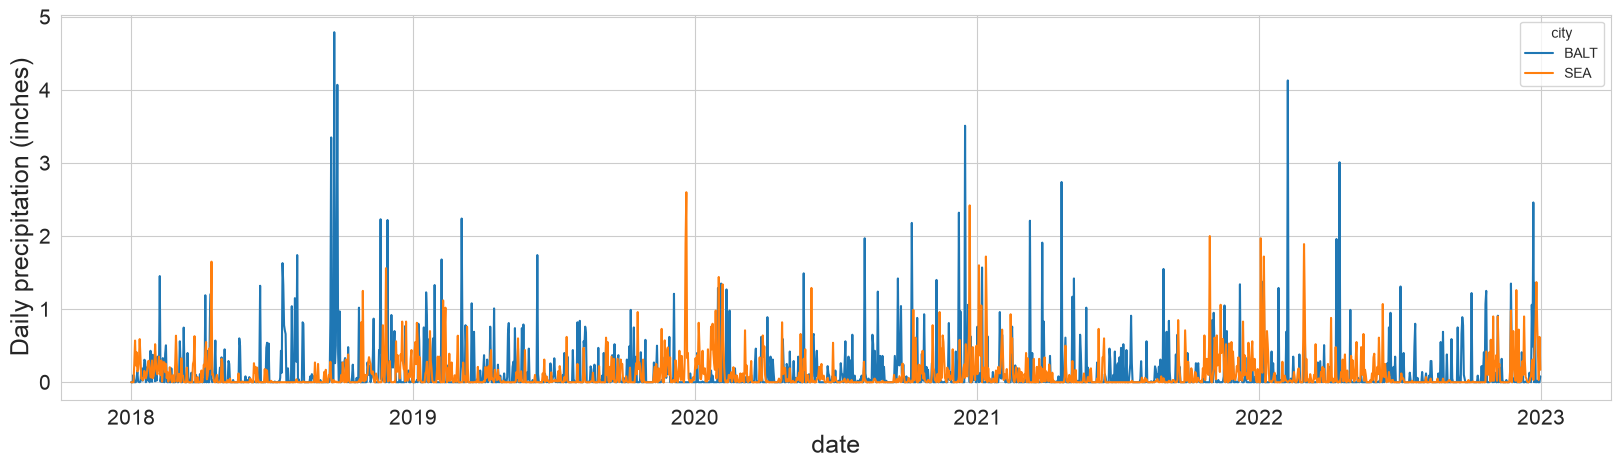

In [70]:
plt.figure(figsize=(20,5))

sns.lineplot(data=df_copy, x='date', y='precipitation', hue='city')

plt.xlabel('date', fontsize=18)
plt.ylabel('Daily precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

Line plot shows the daily precipiation for Seatte (Orange) and Baltimore (Blue) across the entire date range. Upon first glance, it is clear Baltimore has overall higher spikes in rainfall. Seattle appears to have cluseters of higher rainfall towards the end of one year and the beginning of another. A closer inspection will clearly show more trends. 

#### Creating discriptive statistics

In [71]:
df_copy[['city', 'precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
BALT        1826.0  0.141614  0.377065  0.0  0.0  0.00  0.09  4.79
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60

In [72]:
df_copy[['city', 'precipitation']].groupby('city').mean()

,precipitation
city,
BALT,0.141614
SEA,0.113270


Above calculations show that the mean precipitation in Baltimore is aprox. 0.14 inches with a standard deviation of aprox. 0.37. The mean precipiatation in Seattle is 0.11 inches with a standard deviation of 0.24. The maximum precipitation for Baltimore and Seattle is 4.79 inches and 2.60 inches, respectively.

#### Creating a bar plot of mean daily precipitation

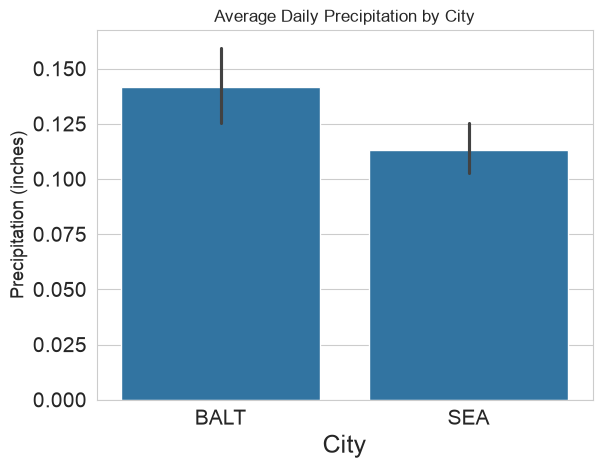

In [175]:
sns.barplot(data=df_copy, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=13)
plt.xlabel('City', fontsize=18)
plt.tick_params(labelsize=15)

plt.title('Average Daily Precipitation by City')

plt.savefig('AveDailyPrecpitation.png')

plt.show()

Barplot shows average daily precipitation in Baltimore and Seattle, including a confidence interval. Average precipitation is higher in Baltimore compared to Seattle.

#### Creating a boxplot of monthly precipitation by city

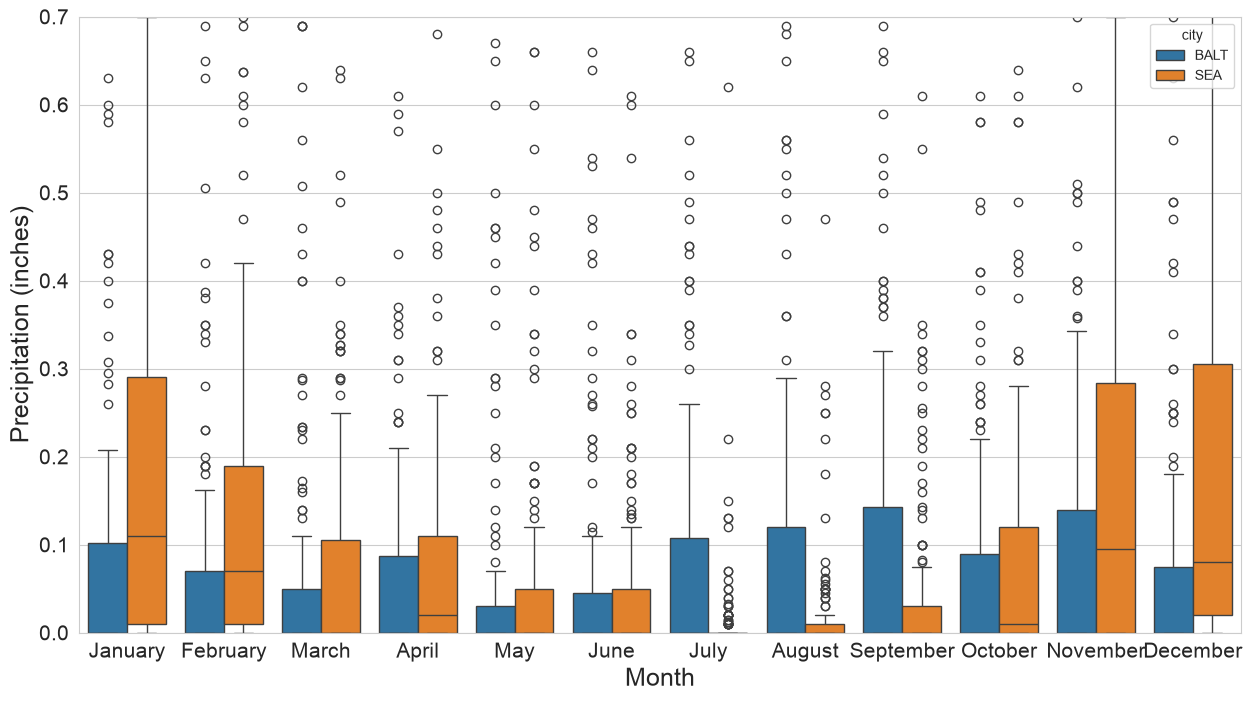

In [76]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df_copy, x='month', y='precipitation',  hue='city')

plt.xlabel('Month', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

import calendar
month_names = list(calendar.month_name[1:])

plt.xticks(ticks=range(12), labels=month_names)

plt.ylim(0,0.7)

plt.show()

This boxplot shows the spread of the precipitation amount by month. Seattle tends to have more precipitation than Baltimore, except during late summer and early fall (July through September). Precipitation in Baltimore and Seattle is roughly similiar during the spring months. Seattle tends to have significantly more precipitation than Baltimore in the winter. While Baltimore is more prone to extremes in precipitaiton throughout the year, Seattle has more consistently higher amounts of rain in winter months. 

#### Calculating mean monthly precipitation and a bar plot of mean monthly precipitation by city. 

In [84]:
df_copy[['month', 'city', 'precipitation']].groupby(['city', 'month']).mean()

precipitation
city month               
BALT 1           0.145876
     2           0.144356
     3           0.123016
     4           0.151750
     5           0.102968
     6           0.088650
     7           0.126887
     8           0.153995
     9           0.214917
     10          0.128065
     11          0.155667
     12          0.164903
SEA  1           0.230742
     2           0.176472
     3           0.089075
     4           0.100483
     5           0.069161
     6           0.063167
     7           0.013984
     8           0.019995
     9           0.055622
     10          0.118452
     11          0.201867
     12          0.224903

This chart shows the monthly precipitation (inches) by city. This confirms that the average precipitation in Seattle tends to be lower than Baltimore during the summer. 

#### Perfoming statistical test for differences in monthly average precipitation.

H<sub>0</sub> : &mu; Seattle, January = &mu; Baltimore, January <br>
H<sub>a</sub> : &mu; Seattle, January &ne; &mu; Baltimore, January <br>
H<sub>0</sub> : &mu; Seattle, Febuary = &mu; Baltimore, Febuary <br>
H<sub>a</sub> : &mu; Seattle, Febuary &ne; &mu; Baltimore, Febuary <br>
.<br>
.<br>
.<br>
H<sub>0</sub> : &mu; Seattle, December = &mu; Baltimore, December <br>
H<sub>a</sub> : &mu; Seattle, December &ne; &mu; Baltimore, December


Examine distribution of precipitation values to confirm Normal Distribution

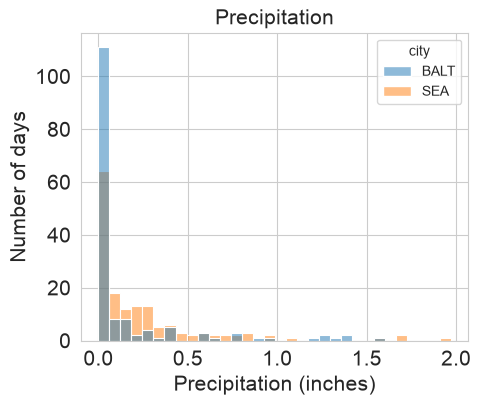

In [119]:
plt.figure(figsize=(5, 4))

sns.histplot(data=df_copy[df_copy['month'] == 1], x='precipitation', hue='city')

plt.xlabel('Precipitation (inches)', fontsize=15)
plt.ylabel('Number of days', fontsize=15)
plt.title('Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

Distribution is right-skewed; therefore, is not normally distributed. However, the sample size is high a t-test, so can be performed anyways. 

In [112]:
significance_level = 0.05
significantly_different = np.zeros(12)


for month in range(1, 13):
    sea_data = df_copy.loc[(df_copy['city'] == 'SEA') & (df_copy['month'] == month), 'precipitation']
    balt_data = df_copy.loc[(df_copy['city'] == 'BALT') & (df_copy['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, balt_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f" t-statistic = {t_statistic:.2f}")
    print(f" p-value t test = {p_value:.3f}")
    print("-" *20)

Month 1:
 t-statistic = 2.24
 p-value t test = 0.026
--------------------
Month 2:
 t-statistic = 0.71
 p-value t test = 0.476
--------------------
Month 3:
 t-statistic = -1.11
 p-value t test = 0.268
--------------------
Month 4:
 t-statistic = -1.34
 p-value t test = 0.181
--------------------
Month 5:
 t-statistic = -1.37
 p-value t test = 0.173
--------------------
Month 6:
 t-statistic = -1.13
 p-value t test = 0.258
--------------------
Month 7:
 t-statistic = -5.05
 p-value t test = 0.000
--------------------
Month 8:
 t-statistic = -4.98
 p-value t test = 0.000
--------------------
Month 9:
 t-statistic = -3.06
 p-value t test = 0.003
--------------------
Month 10:
 t-statistic = -0.30
 p-value t test = 0.763
--------------------
Month 11:
 t-statistic = 1.26
 p-value t test = 0.210
--------------------
Month 12:
 t-statistic = 1.26
 p-value t test = 0.210
--------------------


In [118]:
for month in range(12):
    if significantly_different[month] == 1.:
        print(month)

0
6
7
8


This outputs the results of the t test: The months with their p_value and t-statistic.

#### Creating a barplot of average precipiatation amount with indicator for statistically significant months.

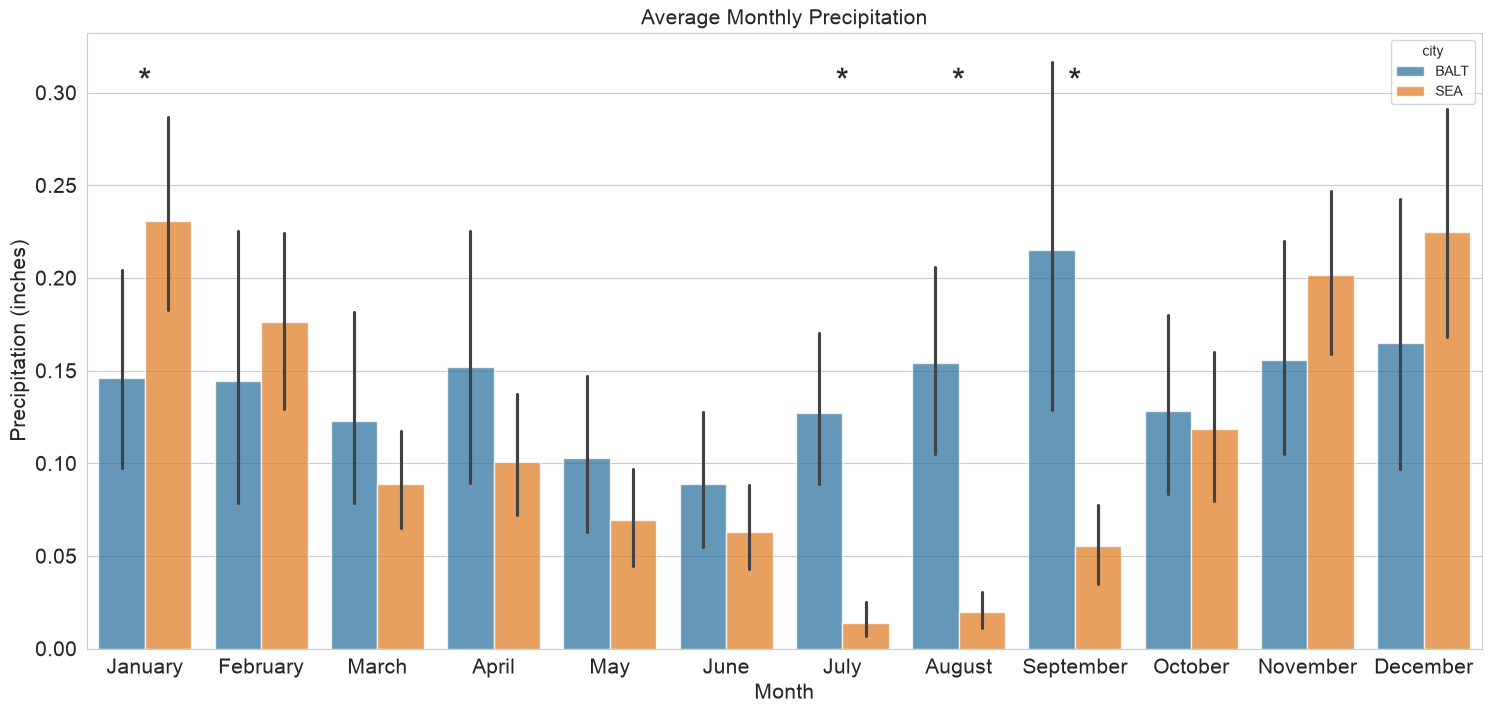

In [115]:
plt.figure(figsize=(18,8))

sns.barplot(data=df_copy, x='month', y='precipitation',  hue='city', alpha=0.75) 

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title('Average Monthly Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

for month in range(12):
    if significantly_different[month] == 1.:

        plt.text(month, 0.3, '*', ha='center', fontsize=25)

plt.show()

The significance level for the difference in average precipitation levels by month have been calculated and visualized.

### Comparing days with precipitation

#### Creating a barplot to compare the proportion of days with rain 

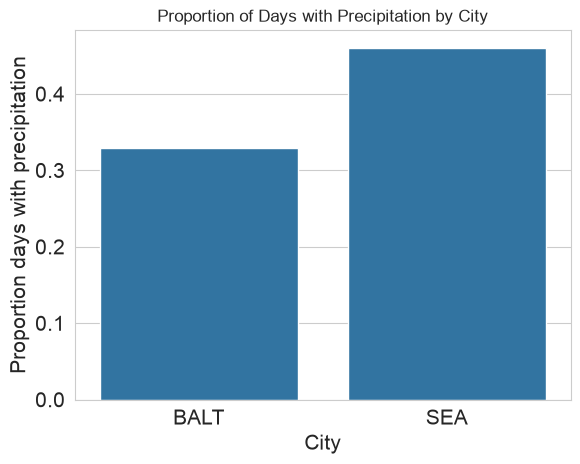

In [171]:
sns.barplot(data=df_copy, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion days with precipitation', fontsize=15)

plt.title('Proportion of Days with Precipitation by City')

plt.tick_params(labelsize=15)

plt.show()

Created a barplot to display the proportion of days with any precipitation in both cities. Seattle has an overall higher proportion of days with precipitation than Baltimore.

#### Plotting the proportion of days with precipitation each month by city. 

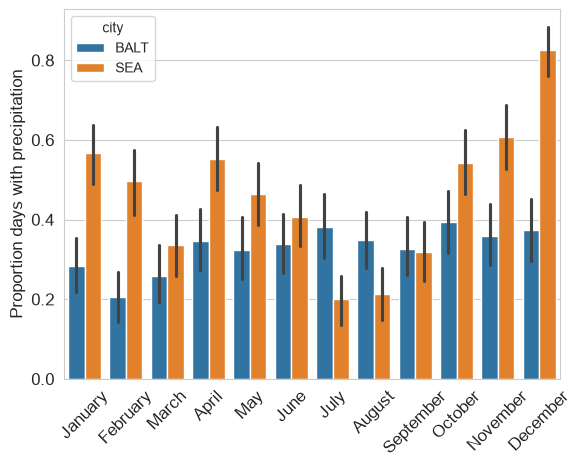

In [81]:
sns.barplot(data=df_copy, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=12)
plt.xticks(ticks=range(12), labels=month_names, rotation=45)

plt.tick_params(labelsize=12)

plt.show()

Barplot shows the variation in proportion of days with rain by month for each city. Overall, Seattle has a higher proportion of days with precipitation per month compared to baltimore.

#### Performing statistical test for the proportion of days with any precipiatation each month using a z test.

H<sub>0</sub> : &rho; Seattle, January = &rho; Baltimore, January <br>
H<sub>a</sub> : &rho; Seattle, January &ne; &rho; Baltimore, January <br>
H<sub>0</sub> : &rho; Seattle, Febuary = &rho; Baltimore, Febuary <br>
H<sub>a</sub> : &rho; Seattle, Febuary &ne; &rho; Baltimore, Febuary <br>
.<br>
.<br>
.<br>
H<sub>0</sub> : &rho; Seattle, December = &rho; Baltimore, December <br>
H<sub>a</sub> : &rho; Seattle, December &ne; &rho; Baltimore, December


In [124]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different = np.zeros(12)

for month in range(1,13):
    
    contingency_table = pd.crosstab(
        df_copy.loc[df_copy['month'] == month, 'city'], df_copy.loc[df_copy['month'] == month, 'any_precipitation']
    )
    
    days_with_precipitation = contingency_table[True]

    total_counts = contingency_table.sum(axis=1)

    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f" z-statistic = {zstat:.2f}")
    print(f" p-value t test = {p_value:.3f}")
    print("-" * 20)

Month 1:
 z-statistic = -5.05
 p-value t test = 0.000
--------------------
Month 2:
 z-statistic = -5.12
 p-value t test = 0.000
--------------------
Month 3:
 z-statistic = -1.49
 p-value t test = 0.136
--------------------
Month 4:
 z-statistic = -3.60
 p-value t test = 0.000
--------------------
Month 5:
 z-statistic = -2.56
 p-value t test = 0.011
--------------------
Month 6:
 z-statistic = -1.19
 p-value t test = 0.233
--------------------
Month 7:
 z-statistic = 3.50
 p-value t test = 0.000
--------------------
Month 8:
 z-statistic = 2.65
 p-value t test = 0.008
--------------------
Month 9:
 z-statistic = 0.12
 p-value t test = 0.902
--------------------
Month 10:
 z-statistic = -2.62
 p-value t test = 0.009
--------------------
Month 11:
 z-statistic = -4.27
 p-value t test = 0.000
--------------------
Month 12:
 z-statistic = -8.12
 p-value t test = 0.000
--------------------


According to the z-test, the months with a statistically signifcant difference in proportion of rainy days are January, May, June, and July.

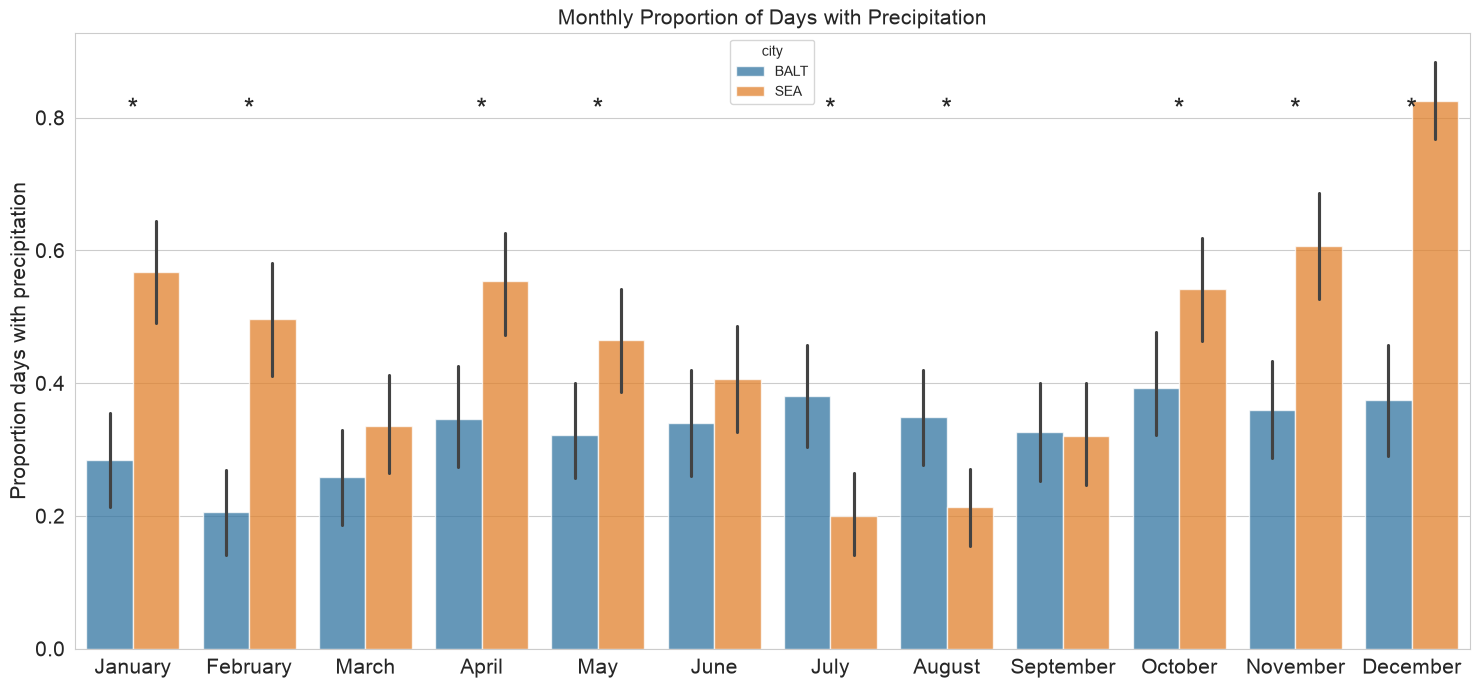

In [125]:
plt.figure(figsize=(18,8))

sns.barplot(data=df_copy, x='month', y='any_precipitation',  hue='city', alpha=0.75) 

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=15)
plt.title('Monthly Proportion of Days with Precipitation', fontsize=15)

plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)

for month in range(12):
    if significantly_different[month] == 1.:

        plt.text(month, 0.8, '*', ha='center', fontsize=20)

plt.show()

The statistical significance has been calculated for the monthly proportion of days with precipitation for the two cities. It appears most months are significantly different, except: March, June, and September. These months do not have a statistically significant difference in proportion of days with precipitation.

### Side by Side comparison of Proportion of rainy days and average rainfall

Creating a chart to display the average amount of precipitation and the proportion of days with rain by month and city.

In [160]:
df_comparison = df_copy[['month', 'city', 'precipitation', 'any_precipitation']].groupby(['city', 'month']).mean()

In [165]:
df_comparison

precipitation  any_precipitation
city month                                  
BALT 1           0.145876           0.283871
     2           0.144356           0.205674
     3           0.123016           0.258065
     4           0.151750           0.346667
     5           0.102968           0.322581
     6           0.088650           0.340000
     7           0.126887           0.380645
     8           0.153995           0.348387
     9           0.214917           0.326667
     10          0.128065           0.393548
     11          0.155667           0.360000
     12          0.164903           0.374194
SEA  1           0.230742           0.567742
     2           0.176472           0.496454
     3           0.089075           0.335484
     4           0.100483           0.553333
     5           0.069161           0.464516
     6           0.063167           0.406667
     7           0.013984           0.200000
     8           0.019995           0.212903
     9           0.055622           0.320000
     10          0.118452           0.541935
     11          0.201867           0.606667
     12          0.224903           0.825806

Interestingly, Seattle has an overall higher proportion of days with rain; whereas, Baltimore has a higher average precipitation amount. This above graph shows a breakdown of precipitation amount and proportion of days with precipitation by month and city.